Thie notebook creates simulations to contextualize the FN and FP rate for the hypothesis "cre of interest is significantly different from minP".
- negative simulations (cre_oi=minP) for quantifying the FP rate.
- positive simulations (cre_oi!=minP) for quantifying FN rate.

# Setup

In [1]:
import scMPRAforge as scm
from dask_jobqueue import SLURMCluster
from dask.distributed import Client, LocalCluster

%load_ext autoreload
%autoreload 2

2026-01-20 14:16:50.771179: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-20 14:16:50.846553: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /apps/software/2024a/software/code-server/4.103.0/lib:/apps/software/2024a/software/gettext/0.22.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libiconv/1.17-GCCcore-13.3.0/lib:/apps/software/2024a/software/ncurses/6.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/apps/software/2024a/software/XZ/5.4.5-GCCcore-13.3.0/lib:/apps/software/2024a/software/expat/2.6.2-GCCcore-13.3.0/lib:/apps/software/2024a/software/cUR

In [2]:
local=False
if local:
    cluster=LocalCluster(memory_limit='48G')
    client=Client(cluster)
else:
    cluster=SLURMCluster(
        cores=2,#cores per slurm job
        memory="32G",#memory per slurm job
        processes=1,#dask workers per slurm jobTrueT
        job_extra_directives=["-p day", 
            f"--job-name=simclust_worker",
            f"--time=4:00:00",
            f"--output=worker_%j.out"]
    )
    cluster.scale(jobs=2)
    client = Client(cluster,
            timeout=f"{5*60}s",   # Client <-> scheduler timeout 
            heartbeat_interval="20s"  # Worker heartbeat interval
        )

In [4]:
data_root="/nfs/roberts/project/pi_skr2/shared/tabula_data"

# Creating artificial libraries

In [ ]:
#making up the CREs
spread_gt,spread_hypothesis=scm.activity_spread(
    cell_types=list(scm.SHENDURE_BOUNDS.cells_per_cell_type.keys()),
    minimum=scm.SHENDURE_BOUNDS.min_mpra_umi,
    maximum=scm.SHENDURE_BOUNDS.max_mpra_umi,
    minp_value=scm.SHENDURE_BOUNDS.reference_activity,
    total=100,
    frac_active=0.5,
    ct_specificity=.2)

libraries=[scm.simulate_library(CREs=spread_gt["cre_id"],
                 library_model=scm.SHENDURE_BOUNDS.library_model)
                 for i in range(5)]

In [ ]:
spread_hypothesis.to_tsv(f"{data_root}/pow_sim_2026-01-03_hypo.tsv")

# Creating sim

In [ ]:
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client,
                            libraries=libraries,
                            library_mapping="corresponding",
                            n_sims=5,
                            experiment_bounds=scm.SHENDURE_BOUNDS,
                            ground_truth=spread_gt)

In [ ]:
sim.gamut()

In [ ]:
sim.save()

# Fit orthos

In [ ]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

In [ ]:
sim.fit_orthos()

In [ ]:
sim.save()

# Wald precompute: sandwich

In [ ]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

In [ ]:
sim.precompute_wald(cov_method="sandwich")

In [ ]:
sim.save()

# Wald precompute: opg

In [ ]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

In [ ]:
sim.precompute_wald(cov_method="opg")

In [ ]:
sim.save()

# Hypothesis testing

In [ ]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

Add a basic hypothesis set

In [ ]:
spread_hypothesis=scm.HypothesisSet.from_tsv(f"{data_root}/pow_sim_2026-01-03_hypo.tsv")

In [ ]:
sim.add_hypothesis_set(name="spread",hypotheses=spread_hypothesis)

Run mwu

In [ ]:
sim.mwu("spread")

In [ ]:
sim.save()

In [ ]:
sim.wald("spread")

In [ ]:
sim.wald("spread",cov_method="opg")

In [ ]:
sim.save()

# Summary

In [ ]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

In [ ]:
sim.list_tests()

In [ ]:
sim.performance_barchart("spread","auprc")

In [ ]:
sim.performance_barchart("spread","auroc")

In [ ]:
sim.median_performance_curve(hypothesis_set_name="spread",performance_type="PRC")

In [ ]:
sim.median_performance_curve(hypothesis_set_name="spread",performance_type="ROC")

A quick example of restricting to only some tests:

In [ ]:
sim.median_performance_curve(hypothesis_set_name="spread",test_types=["mwu","wald_opg"],performance_type="PRC")

# Subset spread hypotheses

In [4]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

scMPRAforge: INFO: 'state.parquet' found for 'pow_sim_2026-01-03', loading.


In [ ]:
import pandas as pd

In [ ]:
hypo=pd.read_csv(sim.testd/"spread"/"hypotheses.tsv",sep="\t")

In [ ]:
hypo

In [ ]:
activity=hypo[hypo["comparison_cell_type"]==hypo["reference_cell_type"]]

In [ ]:
activity

In [ ]:
sim.add_hypothesis_set(name="spread_activity",hypotheses=scm.HypothesisSet(activity))

In [ ]:
specificity=hypo[hypo["comparison_CRE"]==hypo["reference_CRE"]]

In [ ]:
specificity

In [ ]:
sim.add_hypothesis_set(name="spread_specificity",hypotheses=scm.HypothesisSet(specificity))

In [ ]:
sim.mwu("spread_activity")
sim.wald("spread_activity")
sim.wald("spread_activity",cov_method="opg")
sim.save()

In [7]:
sim.mwu("spread_specificity")

In [15]:
sim.wald("spread_specificity")

In [16]:


sim.wald("spread_specificity",cov_method="opg")
sim.save()

KeyboardInterrupt: 

# Activity hypotheses summary

In [5]:
#loading back into mem, assuming notebook shut down after last task
sim=scm.de_novo_simulation(location=data_root,
                            name="pow_sim_2026-01-03",
                            client=client)

scMPRAforge: INFO: 'state.parquet' found for 'pow_sim_2026-01-03', loading.


scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_sandwich, rep:4.


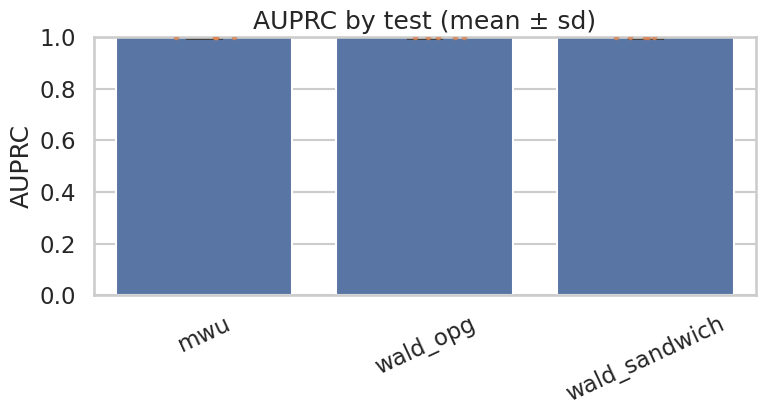

In [9]:
sim.performance_barchart("spread_activity","auprc")

scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_sandwich, rep:4.


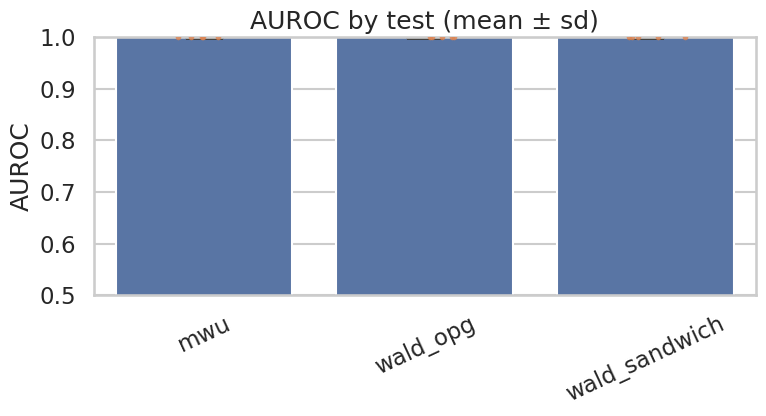

In [10]:
sim.performance_barchart("spread_activity","auroc")

scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_sandwich, rep:4.


Called positive: 521 / 1000 (52.1000%)
Called positive: 565 / 1000 (56.5000%)
Called positive: 565 / 1000 (56.5000%)


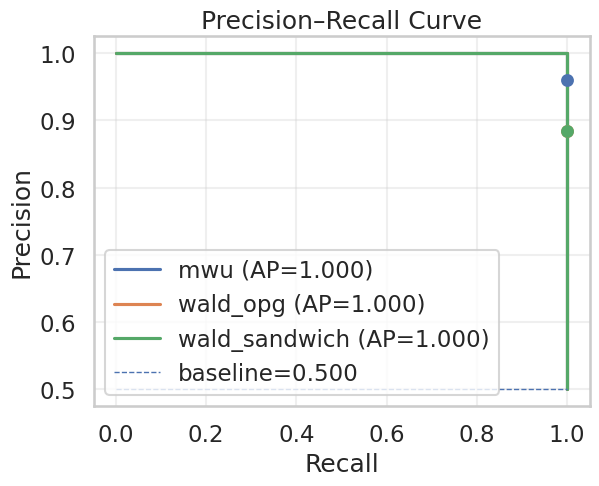

In [12]:
sim.median_performance_curve(hypothesis_set_name="spread_activity",performance_type="PRC")

scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:3.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_opg, rep:4.
scMPRAforge: INFO: Dropped 1 or 0.1% of tests with NA values for test:wald_sandwich, rep:4.


Called positive: 521 / 1000 (52.1000%)
Called positive: 565 / 1000 (56.5000%)
Called positive: 565 / 1000 (56.5000%)


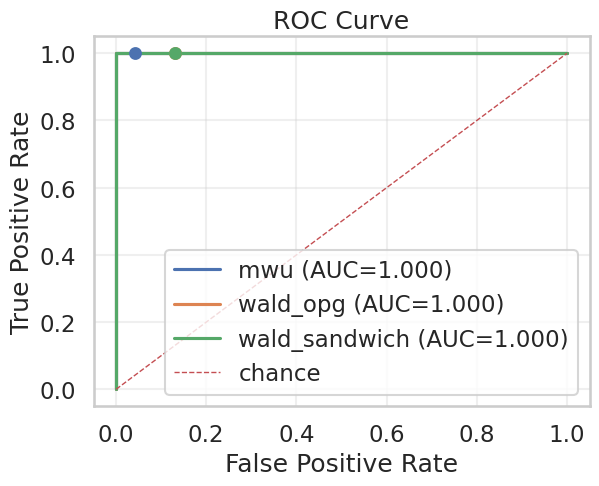

In [14]:
sim.median_performance_curve(hypothesis_set_name="spread_activity",performance_type="ROC")

In [ ]:
sim.median_performance_curve(hypothesis_set_name="spread_specificity",performance_type="PRC")

# Specificity hypotheses summary

# Test of fdr plot

not relevant for these sims, but testing...

# Shutdown

In [17]:
client.close()
cluster.close()